In [13]:
# This script:
# 1. Downloads price data for 5 ETFs (US stocks, intl stocks, bonds, commodities, real estate)
# 2. Fetches risk‑free rate from FRED using fredapi (direct key insertion)
# 3. Computes implied equilibrium returns from market weights
# 4. Defines investor views
# 5. Applies Black‑Litterman formula to get posterior returns
# 6. Performs mean‑variance optimization (max Sharpe) with constraints
# 7. Backtests the strategy with monthly rebalancing and compares to benchmarks
# 8. Plots results

import numpy as np
import pandas as pd
import yfinance as yf
from fredapi import Fred
import scipy.optimize as sco
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [8]:
pip install fredapi


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
# ============================================================
# 1. PARAMETERS & DATA DOWNLOAD
# ============================================================
tickers = ['SPY', 'EFA', 'AGG', 'GSG', 'VNQ']   # ETFs
names = ['US Equities', 'Intl Equities', 'Bonds', 'Commodities', 'Real Estate']
start = '2018-01-01'
end = '2023-12-31'

# Download adjusted close prices from Yahoo Finance
print("Downloading price data from Yahoo Finance...")
prices = yf.download(tickers, start=start, end=end, auto_adjust=True)['Close']
prices = prices.dropna()
print("Price data downloaded.")

[*********************100%***********************]  5 of 5 completed

Price data downloaded.


In [30]:
# ============================================================
# 2. RISK‑FREE RATE FROM FRED (DIRECT API KEY)
# ============================================================
# !!! REPLACE 'your_actual_api_key_here' WITH YOUR REAL FRED API KEY !!!
FRED_API_KEY = 'fred_api_key'   # <-- PASTE YOUR KEY HERE

try:
    fred = Fred(api_key=FRED_API_KEY)
    # DGS3MO = 3‑Month Treasury Constant Maturity Rate (daily, %)
    rf_data = fred.get_series('DGS3MO', start=start, end=end)
    # Convert from percent to decimal and take average (annual rate)
    rf = rf_data.mean() / 100.0
    print(f"Risk‑free rate from FRED: {rf:.2%}")
except Exception as e:
    print(f"Error fetching from FRED: {e}")
    print("Using default 2% annual rate.")
    rf = 0.02

Risk‑free rate from FRED: 3.83%


In [31]:
# ============================================================
# 3. DAILY RETURNS AND ANNUALISED COVARIANCE
# ============================================================
returns = prices.pct_change().dropna()
cov = returns.cov() * 252   # annualised covariance
hist_returns = returns.mean() * 252   # historical annualised mean returns (for reference)

In [32]:
# ============================================================
# 4. MARKET WEIGHTS (APPROXIMATE)
# ============================================================
# For this example, we assume a simple market‑cap weighted mix.
market_weights = np.array([0.40, 0.30, 0.20, 0.05, 0.05])
w_mkt = market_weights

In [33]:
# ============================================================
# 5. IMPLIED EQUILIBRIUM RETURNS (PRIOR)
# ============================================================
# Compute market portfolio excess return and variance
excess_market_return = np.dot(w_mkt, hist_returns) - rf
market_var = np.dot(w_mkt.T, np.dot(cov, w_mkt))
lambda_ = excess_market_return / market_var   # risk aversion

# Equilibrium excess returns (CAPM implied)
mu_eq = lambda_ * np.dot(cov, w_mkt)
mu_eq = pd.Series(mu_eq, index=tickers, name='Equilibrium Excess Return')
print("\nEquilibrium excess returns:\n", mu_eq)


Equilibrium excess returns:
 SPY    0.001339
EFA    0.010256
AGG    0.010325
GSG    0.010328
VNQ    0.010665
Name: Equilibrium Excess Return, dtype: float64


In [34]:
# ============================================================
# 6. INVESTOR VIEWS
# ============================================================
# View 1: US Equities (SPY) will outperform International Equities (EFA) by 3% per year.
# View 2: Commodities (GSG) will have an absolute excess return of 2% per year.

P = np.array([
    [1, -1, 0, 0, 0],   # SPY - EFA
    [0, 0, 0, 1, 0]     # GSG
])
Q = np.array([0.03, 0.02])   # annual excess returns

# Confidence (uncertainty) in views
# We set the variance of each view proportional to the variance of the view portfolio.
tau = 0.05   # prior uncertainty scalar

view1_var = P[0] @ cov @ P[0].T
view2_var = P[1] @ cov @ P[1].T
# Scale by a confidence factor (here 0.5). Smaller = more confident.
omega_diag = np.array([view1_var, view2_var]) * 0.5
Omega = np.diag(omega_diag)

In [35]:
# ============================================================
# 7. BLACK‑LITTERMAN FORMULA
# ============================================================
prior_cov = tau * cov
prior_cov_inv = np.linalg.inv(prior_cov)
P_Omega_P = P.T @ np.linalg.inv(Omega) @ P

A = prior_cov_inv + P_Omega_P
b = prior_cov_inv @ mu_eq + P.T @ np.linalg.inv(Omega) @ Q
mu_bl = np.linalg.solve(A, b)   # posterior excess returns
mu_bl = pd.Series(mu_bl, index=tickers, name='BL Excess Return')
print("\nBlack‑Litterman excess returns:\n", mu_bl)


Black‑Litterman excess returns:
 SPY    0.001559
EFA    0.007765
AGG    0.009133
GSG    0.008224
VNQ    0.008792
Name: BL Excess Return, dtype: float64


In [36]:
# ============================================================
# 8. MEAN‑VARIANCE OPTIMIZATION (MAX SHARPE)
# ============================================================
def portfolio_stats(weights, mu, cov, rf):
    ret = np.dot(weights, mu) + rf   # total return
    vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    sharpe = (ret - rf) / vol
    return ret, vol, sharpe

def neg_sharpe(weights, mu, cov, rf):
    return -portfolio_stats(weights, mu, cov, rf)[2]

# Constraints: fully invested, long‑only with individual cap 20%
cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = tuple((0, 0.2) for _ in range(len(tickers)))
init_guess = [1./len(tickers)] * len(tickers)

# Optimize for BL returns
opt_bl = sco.minimize(neg_sharpe, init_guess, args=(mu_bl, cov, rf),
                      method='SLSQP', bounds=bounds, constraints=cons)
w_bl = opt_bl.x if opt_bl.success else init_guess

# Optimize for equilibrium returns (for comparison)
opt_eq = sco.minimize(neg_sharpe, init_guess, args=(mu_eq, cov, rf),
                      method='SLSQP', bounds=bounds, constraints=cons)
w_eq = opt_eq.x if opt_eq.success else init_guess

# Equal weight and market weight benchmarks
w_equal = np.array([1./len(tickers)] * len(tickers))
w_mkt = market_weights

# Print portfolios
def print_portfolio(name, weights, mu, cov, rf):
    ret, vol, sharpe = portfolio_stats(weights, mu, cov, rf)
    print(f"\n{name}:")
    for t, w in zip(tickers, weights):
        print(f"  {t}: {w:.2%}")
    print(f"  Expected Return: {ret:.2%}")
    print(f"  Expected Volatility: {vol:.2%}")
    print(f"  Sharpe Ratio: {sharpe:.2f}")

print("\n========== OPTIMAL PORTFOLIOS ==========")
print_portfolio("Black‑Litterman", w_bl, mu_bl, cov, rf)
print_portfolio("Equilibrium (Prior)", w_eq, mu_eq, cov, rf)
print_portfolio("Market Cap", w_mkt, mu_eq, cov, rf)
print_portfolio("Equal Weight", w_equal, hist_returns, cov, rf)


========== OPTIMAL PORTFOLIOS ==========

Black‑Litterman:
  SPY: 20.00%
  EFA: 20.00%
  AGG: 20.00%
  GSG: 20.00%
  VNQ: 20.00%
  Expected Return: 4.54%
  Expected Volatility: 14.40%
  Sharpe Ratio: 0.05

Equilibrium (Prior):
  SPY: 20.00%
  EFA: 20.00%
  AGG: 20.00%
  GSG: 20.00%
  VNQ: 20.00%
  Expected Return: 4.69%
  Expected Volatility: 14.40%
  Sharpe Ratio: 0.06

Market Cap:
  SPY: 40.00%
  EFA: 30.00%
  AGG: 20.00%
  GSG: 5.00%
  VNQ: 5.00%
  Expected Return: 4.50%
  Expected Volatility: 10.93%
  Sharpe Ratio: 0.06

Equal Weight:
  SPY: 20.00%
  EFA: 20.00%
  AGG: 20.00%
  GSG: 20.00%
  VNQ: 20.00%
  Expected Return: 10.70%
  Expected Volatility: 14.40%
  Sharpe Ratio: 0.48


In [37]:
# ============================================================
# 9. BACKTEST WITH MONTHLY REBALANCING
# ============================================================
window = 252                # estimation window for covariance
rebalance_freq = 21         # rebalance every 21 trading days (~monthly)
max_weight = 0.2            # same diversification cap

# Store weights and returns
dates = returns.index[window:]
rebalance_dates = dates[::rebalance_freq]

portfolio_returns_bl = pd.Series(index=returns.index, dtype=float)
portfolio_returns_mkt = pd.Series(index=returns.index, dtype=float)
portfolio_returns_eq = pd.Series(index=returns.index, dtype=float)
portfolio_returns_hist = pd.Series(index=returns.index, dtype=float)

print("\nRunning backtest...")


for i, rebal_date in enumerate(rebalance_dates):
    # End of estimation window (day before rebalance)
    end_idx = returns.index.get_loc(rebal_date) - 1
    if end_idx < window:
        continue
    start_idx = end_idx - window + 1
    hist_returns_window = returns.iloc[start_idx:end_idx+1]

    # Covariance and historical mean
    cov_window = hist_returns_window.cov() * 252
    hist_mean_window = hist_returns_window.mean() * 252

    # Equilibrium returns (using fixed market weights)
    excess_mkt_win = np.dot(w_mkt, hist_mean_window) - rf
    mkt_var_win = np.dot(w_mkt.T, np.dot(cov_window, w_mkt))
    lambda_win = excess_mkt_win / mkt_var_win if mkt_var_win != 0 else lambda_
    mu_eq_win = lambda_win * np.dot(cov_window, w_mkt)

    # View uncertainties based on current covariance
    view1_var_win = P[0] @ cov_window @ P[0].T
    view2_var_win = P[1] @ cov_window @ P[1].T
    omega_diag_win = np.array([view1_var_win, view2_var_win]) * 0.5
    Omega_win = np.diag(omega_diag_win)

    # Black‑Litterman posterior
    prior_cov_win = tau * cov_window
    prior_cov_inv_win = np.linalg.inv(prior_cov_win)
    P_Omega_P_win = P.T @ np.linalg.inv(Omega_win) @ P
    A_win = prior_cov_inv_win + P_Omega_P_win
    b_win = prior_cov_inv_win @ mu_eq_win + P.T @ np.linalg.inv(Omega_win) @ Q
    mu_bl_win = np.linalg.solve(A_win, b_win)

    # Optimize for BL
    opt_bl_win = sco.minimize(neg_sharpe, init_guess, args=(mu_bl_win, cov_window, rf),
                              method='SLSQP', bounds=bounds, constraints=cons)
    w_bl_win = opt_bl_win.x if opt_bl_win.success else init_guess

    # Optimize using historical mean (for comparison)
    opt_hist_win = sco.minimize(neg_sharpe, init_guess, args=(hist_mean_window, cov_window, rf),
                                method='SLSQP', bounds=bounds, constraints=cons)
    w_hist_win = opt_hist_win.x if opt_hist_win.success else init_guess

    # Equal weight and market weight
    w_eq_win = w_equal
    w_mkt_win = w_mkt

    # Determine holding period
    if i < len(rebalance_dates) - 1:
        next_date = rebalance_dates[i+1]
        holding_idx = returns.index[(returns.index >= rebal_date) & (returns.index < next_date)]
    else:
        holding_idx = returns.index[returns.index >= rebal_date]

    # Compute daily portfolio returns for this holding period
    for date in holding_idx:
        if date in returns.index:
            daily_ret = returns.loc[date].values
            portfolio_returns_bl.loc[date] = np.dot(w_bl_win, daily_ret)
            portfolio_returns_mkt.loc[date] = np.dot(w_mkt_win, daily_ret)
            portfolio_returns_eq.loc[date] = np.dot(w_eq_win, daily_ret)
            portfolio_returns_hist.loc[date] = np.dot(w_hist_win, daily_ret)

# Drop NaNs
portfolio_returns_bl = portfolio_returns_bl.dropna()
portfolio_returns_mkt = portfolio_returns_mkt.dropna()
portfolio_returns_eq = portfolio_returns_eq.dropna()
portfolio_returns_hist = portfolio_returns_hist.dropna()



Running backtest...



========== BACKTEST PERFORMANCE ==========
BL                  : Ann Ret = 7.47%, Ann Vol = 15.22%, Sharpe = 0.36
Market              : Ann Ret = 5.42%, Ann Vol = 11.56%, Sharpe = 0.30
Equal Weight        : Ann Ret = 7.47%, Ann Vol = 15.22%, Sharpe = 0.36
Historical Mean‑Var : Ann Ret = 7.47%, Ann Vol = 15.22%, Sharpe = 0.36


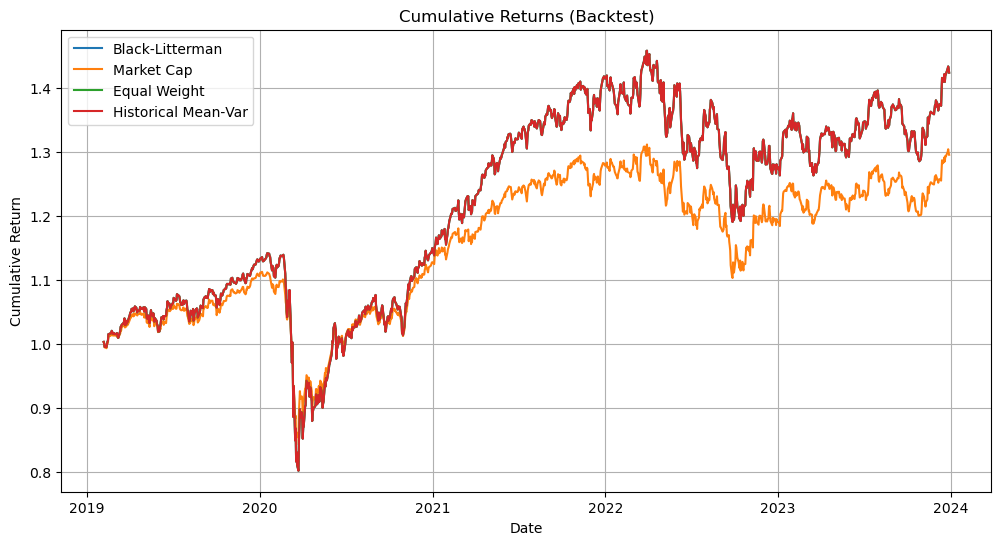

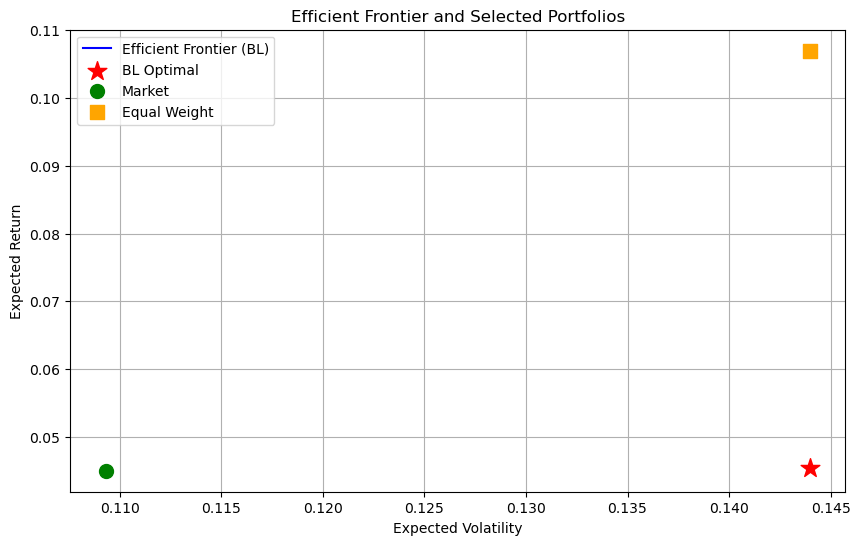

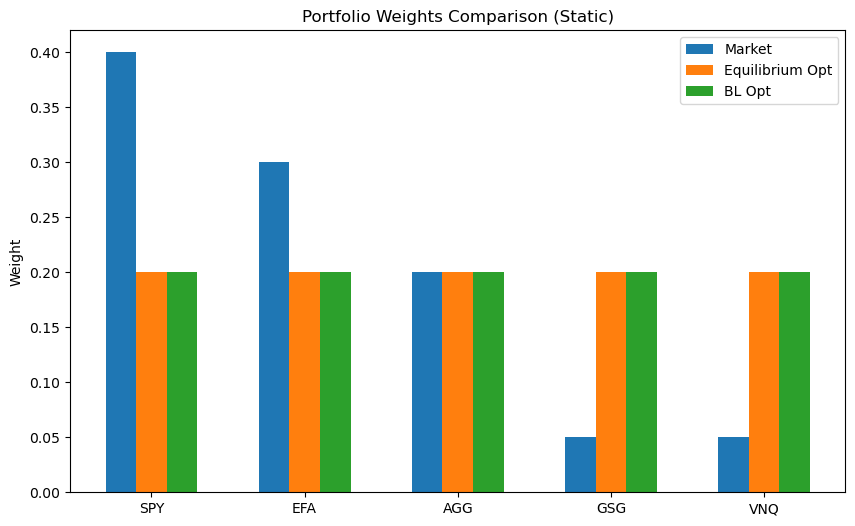


✅ Done.


In [39]:
# ============================================================
# 10. PERFORMANCE METRICS & PLOTS
# ============================================================
def metrics(ret_series, rf=0.02, periods_per_year=252):
    total_ret = (1 + ret_series).prod() - 1
    years = len(ret_series) / periods_per_year
    ann_ret = (1 + total_ret) ** (1/years) - 1
    ann_vol = ret_series.std() * np.sqrt(periods_per_year)
    sharpe = (ann_ret - rf) / ann_vol
    return ann_ret, ann_vol, sharpe

print("\n========== BACKTEST PERFORMANCE ==========")
for name, ret_series in [('BL', portfolio_returns_bl),
                         ('Market', portfolio_returns_mkt),
                         ('Equal Weight', portfolio_returns_eq),
                         ('Historical Mean‑Var', portfolio_returns_hist)]:
    ann_ret, ann_vol, sharpe = metrics(ret_series)
    print(f"{name:20s}: Ann Ret = {ann_ret:.2%}, Ann Vol = {ann_vol:.2%}, Sharpe = {sharpe:.2f}")
    
# Cumulative returns
cum_bl = (1 + portfolio_returns_bl).cumprod()
cum_mkt = (1 + portfolio_returns_mkt).cumprod()
cum_eq = (1 + portfolio_returns_eq).cumprod()
cum_hist = (1 + portfolio_returns_hist).cumprod()

plt.figure(figsize=(12,6))
plt.plot(cum_bl.index, cum_bl, label='Black‑Litterman')
plt.plot(cum_mkt.index, cum_mkt, label='Market Cap')
plt.plot(cum_eq.index, cum_eq, label='Equal Weight')
plt.plot(cum_hist.index, cum_hist, label='Historical Mean‑Var')
plt.title('Cumulative Returns (Backtest)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.savefig('cumulative_returns.png')   # Save to file
plt.show() 

# Efficient frontier (static, using full‑sample covariance and BL returns)
def efficient_frontier(mu, cov, rf, num_points=50):
    target_returns = np.linspace(mu.min(), mu.max(), num_points)
    eff_vols = []
    for tr in target_returns:
        cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
                {'type': 'eq', 'fun': lambda w: portfolio_stats(w, mu, cov, rf)[0] - tr}]
        opt = sco.minimize(lambda w: portfolio_stats(w, mu, cov, rf)[1],
                           init_guess, method='SLSQP', bounds=bounds, constraints=cons)
        if opt.success:
            eff_vols.append(opt.fun)
        else:
            eff_vols.append(np.nan)
    return target_returns, eff_vols

bl_returns, bl_vols = efficient_frontier(mu_bl, cov, rf)

plt.figure(figsize=(10,6))
plt.plot(bl_vols, bl_returns, 'b-', label='Efficient Frontier (BL)')
plt.scatter(portfolio_stats(w_bl, mu_bl, cov, rf)[1],
            portfolio_stats(w_bl, mu_bl, cov, rf)[0],
            marker='*', color='red', s=200, label='BL Optimal')
plt.scatter(portfolio_stats(w_mkt, mu_eq, cov, rf)[1],
            portfolio_stats(w_mkt, mu_eq, cov, rf)[0],
            marker='o', color='green', s=100, label='Market')
plt.scatter(portfolio_stats(w_equal, hist_returns, cov, rf)[1],
            portfolio_stats(w_equal, hist_returns, cov, rf)[0],
            marker='s', color='orange', s=100, label='Equal Weight')
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier and Selected Portfolios')
plt.legend()
plt.grid(True)
plt.show()

# Bar chart of weights (static)
x = np.arange(len(tickers))
width = 0.2
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width, w_mkt, width, label='Market')
ax.bar(x, w_eq, width, label='Equilibrium Opt')
ax.bar(x + width, w_bl, width, label='BL Opt')
ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.set_ylabel('Weight')
ax.set_title('Portfolio Weights Comparison (Static)')
ax.legend()
plt.show()

print("\n✅ Done.")

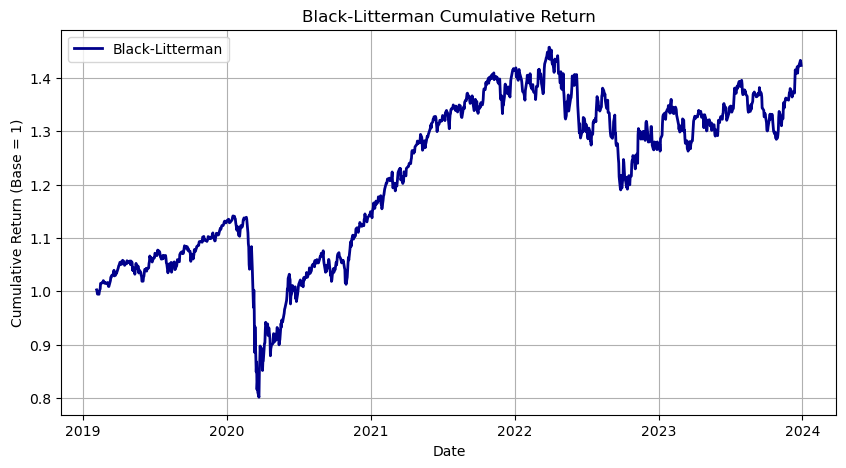

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(cum_bl.index, cum_bl, color='darkblue', linewidth=2, label='Black‑Litterman')
plt.title('Black‑Litterman Cumulative Return')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Base = 1)')
plt.grid(True)
plt.legend()
plt.show()


SENSITIVITY ANALYSIS: EFFECT OF MAX WEIGHT AND TAU

>>> TAU = 0.01 (lower = more prior weight)
maxw = 0.2: Sharpe = 0.057 | SPY: 20.0% EFA: 20.0% AGG: 20.0% GSG: 20.0% VNQ: 20.0%
maxw = 0.3: Sharpe = 0.059 | SPY: 30.0% EFA: 30.0% AGG: 24.2% GSG: 7.6% VNQ: 8.2%
maxw = 0.4: Sharpe = 0.059 | SPY: 40.0% EFA: 27.2% AGG: 20.9% GSG: 6.3% VNQ: 5.6%
maxw = 0.5: Sharpe = 0.059 | SPY: 42.8% EFA: 27.2% AGG: 20.0% GSG: 4.7% VNQ: 5.3%
maxw = 0.6: Sharpe = 0.059 | SPY: 42.8% EFA: 27.2% AGG: 20.0% GSG: 4.7% VNQ: 5.3%
maxw = 0.7: Sharpe = 0.059 | SPY: 42.8% EFA: 27.2% AGG: 20.0% GSG: 4.7% VNQ: 5.3%
maxw = 0.8: Sharpe = 0.059 | SPY: 42.8% EFA: 27.2% AGG: 20.0% GSG: 4.7% VNQ: 5.3%
maxw = 0.9: Sharpe = 0.059 | SPY: 42.8% EFA: 27.2% AGG: 20.0% GSG: 4.7% VNQ: 5.3%
maxw = 1.0: Sharpe = 0.059 | SPY: 42.8% EFA: 27.2% AGG: 20.0% GSG: 4.7% VNQ: 5.3%

>>> TAU = 0.05 (lower = more prior weight)
maxw = 0.2: Sharpe = 0.049 | SPY: 20.0% EFA: 20.0% AGG: 20.0% GSG: 20.0% VNQ: 20.0%
maxw = 0.3: Sharpe = 0.051 | SPY: 30

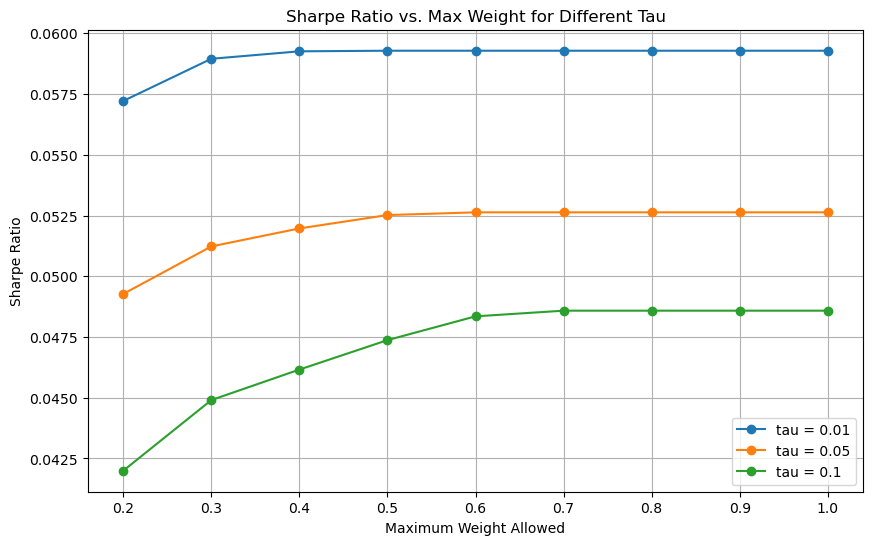

In [41]:
# ============================================================
# SENSITIVITY ANALYSIS: MAX WEIGHT AND TAU
# ============================================================
# We'll test different maximum weights and tau values to see their effect.

# Define the range of max weights (as fractions of portfolio)
max_weights_to_test = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]   # 1.0 = no cap
# Define tau values to test (smaller = more confidence in prior)
tau_values = [0.01, 0.05, 0.1]

# Store results for comparison
results = []

print("\n" + "="*70)
print("SENSITIVITY ANALYSIS: EFFECT OF MAX WEIGHT AND TAU")
print("="*70)

for tau_val in tau_values:
    print(f"\n>>> TAU = {tau_val} (lower = more prior weight)")

    # Recompute BL posterior with this tau
    prior_cov = tau_val * cov
    prior_cov_inv = np.linalg.inv(prior_cov)
    P_Omega_P = P.T @ np.linalg.inv(Omega) @ P
    A = prior_cov_inv + P_Omega_P
    b = prior_cov_inv @ mu_eq + P.T @ np.linalg.inv(Omega) @ Q
    mu_bl_sens = np.linalg.solve(A, b)
    mu_bl_sens = pd.Series(mu_bl_sens, index=tickers)

    for maxw in max_weights_to_test:
        # Set bounds: long‑only, upper bound = maxw
        bounds_sens = tuple((0, maxw) for _ in range(len(tickers)))

        # Optimize for BL returns
        opt_bl_sens = sco.minimize(neg_sharpe, init_guess, args=(mu_bl_sens, cov, rf),
                                   method='SLSQP', bounds=bounds_sens, constraints=cons)
        w_bl_sens = opt_bl_sens.x if opt_bl_sens.success else init_guess

        # Compute portfolio stats
        ret_bl, vol_bl, sharpe_bl = portfolio_stats(w_bl_sens, mu_bl_sens, cov, rf)

        # Store for summary
        results.append({
            'tau': tau_val,
            'max_weight': maxw,
            'weights': w_bl_sens.copy(),
            'ret': ret_bl,
            'vol': vol_bl,
            'sharpe': sharpe_bl
        })

        # Print a concise line for this combination
        weight_str = " ".join([f"{t}: {w:.1%}" for t, w in zip(tickers, w_bl_sens)])
        print(f"maxw = {maxw:.1f}: Sharpe = {sharpe_bl:.3f} | {weight_str}")

# ============================================================
# HIGHLIGHT EXTREME CASES: NO CAP (maxw = 1.0) AND LOW TAU
# ============================================================
print("\n" + "="*70)
print("DETAILED VIEW FOR NO CAP (maxw = 1.0) AND DIFFERENT TAU")
print("="*70)
for tau_val in tau_values:
    # Recompute BL posterior with this tau
    prior_cov = tau_val * cov
    prior_cov_inv = np.linalg.inv(prior_cov)
    P_Omega_P = P.T @ np.linalg.inv(Omega) @ P
    A = prior_cov_inv + P_Omega_P
    b = prior_cov_inv @ mu_eq + P.T @ np.linalg.inv(Omega) @ Q
    mu_bl_sens = np.linalg.solve(A, b)
    mu_bl_sens = pd.Series(mu_bl_sens, index=tickers)

    bounds_nocap = tuple((0, 1.0) for _ in range(len(tickers)))
    opt_nocap = sco.minimize(neg_sharpe, init_guess, args=(mu_bl_sens, cov, rf),
                             method='SLSQP', bounds=bounds_nocap, constraints=cons)
    w_nocap = opt_nocap.x if opt_nocap.success else init_guess
    ret_nocap, vol_nocap, sharpe_nocap = portfolio_stats(w_nocap, mu_bl_sens, cov, rf)

    print(f"\nTAU = {tau_val}:")
    for t, w in zip(tickers, w_nocap):
        print(f"  {t}: {w:.2%}")
    print(f"  Expected Return: {ret_nocap:.2%}")
    print(f"  Expected Volatility: {vol_nocap:.2%}")
    print(f"  Sharpe Ratio: {sharpe_nocap:.3f}")

# ============================================================
# OPTIONAL: PLOT SHARPE RATIO VS MAX WEIGHT FOR DIFFERENT TAU
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for tau_val in tau_values:
    subset = [r for r in results if r['tau'] == tau_val]
    x = [r['max_weight'] for r in subset]
    y = [r['sharpe'] for r in subset]
    plt.plot(x, y, marker='o', label=f'tau = {tau_val}')
plt.xlabel('Maximum Weight Allowed')
plt.ylabel('Sharpe Ratio')
plt.title('Sharpe Ratio vs. Max Weight for Different Tau')
plt.legend()
plt.grid(True)
plt.show()


CUMULATIVE RETURNS FOR DIFFERENT TAU AND MAX WEIGHT (STATIC PORTFOLIOS)


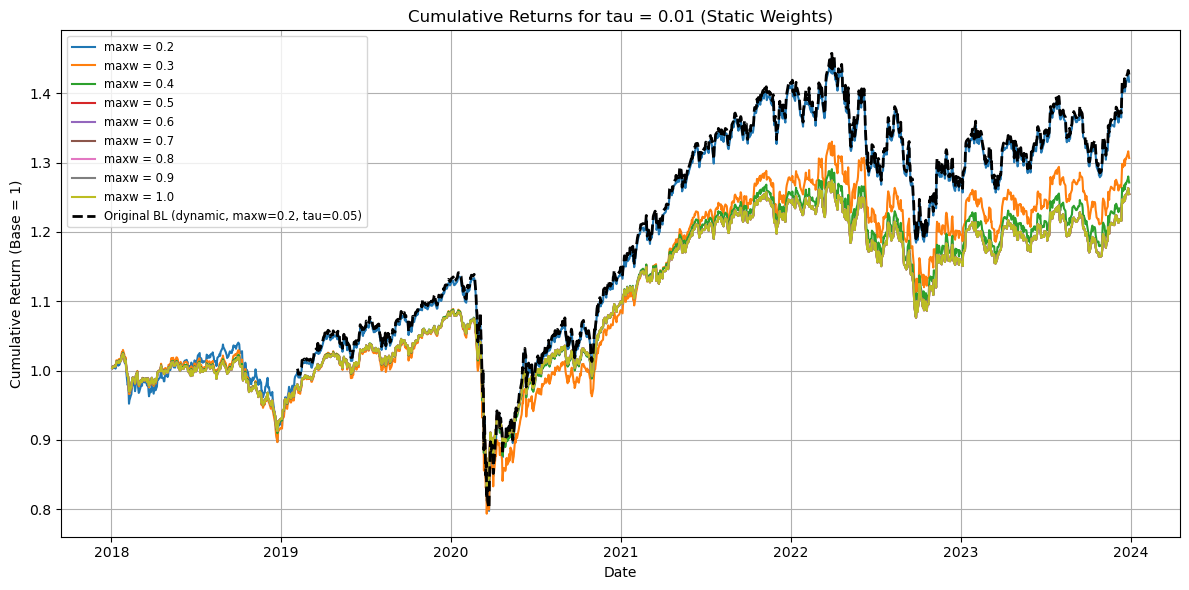

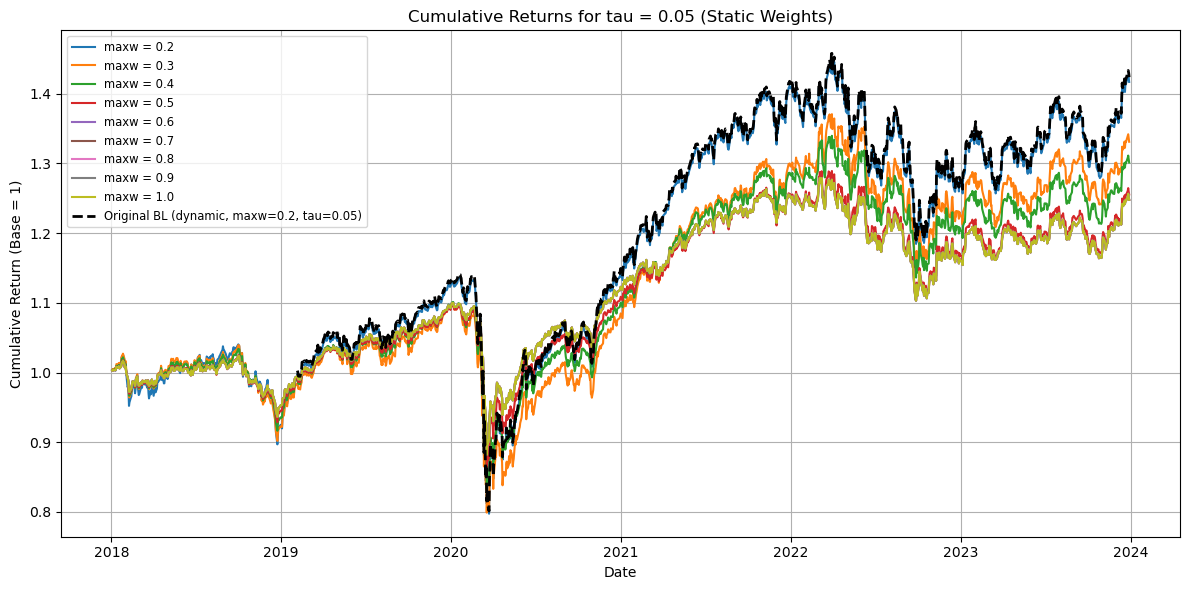

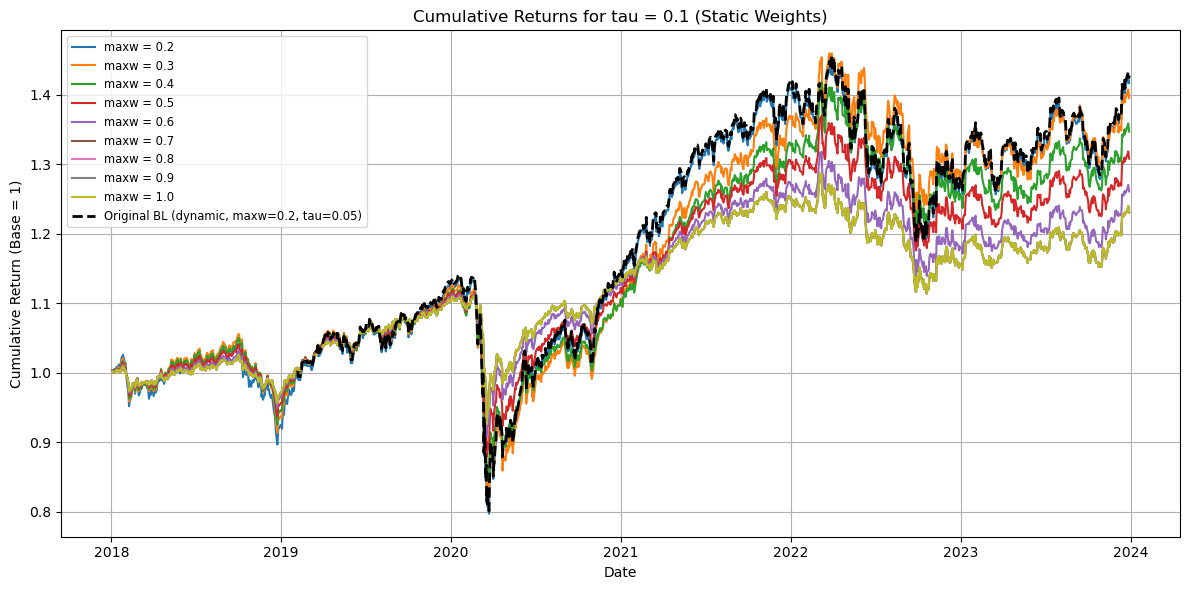

In [43]:
# ============================================================
# CUMULATIVE RETURNS FOR SENSITIVITY CASES (STATIC WEIGHTS)
# ============================================================
print("\n" + "="*70)
print("CUMULATIVE RETURNS FOR DIFFERENT TAU AND MAX WEIGHT (STATIC PORTFOLIOS)")
print("="*70)

# Ensure we have the daily returns series (from earlier)
# returns is the daily returns DataFrame from the original data.

# We'll create a dictionary to store cumulative return series
cum_series_dict = {}

# For each tau and max weight, compute static portfolio cumulative returns
for tau_val in tau_values:
    for maxw in max_weights_to_test:
        # Retrieve the stored weights for this combination
        # We need to find the result with matching tau and maxw
        matching = [r for r in results if r['tau'] == tau_val and r['max_weight'] == maxw]
        if not matching:
            continue
        w = matching[0]['weights']

        # Compute daily portfolio returns (static weights)
        port_returns = returns.dot(w)   # dot product with asset returns for each day
        # Cumulative product starting from 1
        cum_ret = (1 + port_returns).cumprod()
        cum_ret.name = f"tau={tau_val}, maxw={maxw}"
        cum_series_dict[(tau_val, maxw)] = cum_ret

# Plot separate figures for each tau
for tau_val in tau_values:
    plt.figure(figsize=(12,6))

    # Plot lines for each max weight
    for maxw in max_weights_to_test:
        key = (tau_val, maxw)
        if key in cum_series_dict:
            cum_ret = cum_series_dict[key]
            plt.plot(cum_ret.index, cum_ret, label=f'maxw = {maxw}')

    # Add the original dynamic BL cumulative return (with tau=0.05, maxw=0.2) as a reference
    if 'cum_bl' in locals():
        plt.plot(cum_bl.index, cum_bl, 'k--', label='Original BL (dynamic, maxw=0.2, tau=0.05)', linewidth=2)

    plt.title(f'Cumulative Returns for tau = {tau_val} (Static Weights)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return (Base = 1)')
    plt.legend(loc='upper left', fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'cumulative_returns_tau_{tau_val}.png', dpi=150)
    plt.show()

